## Feature Engineering

## Feature Engineering

#### 0. Import data


Data set tomado de esta url: https://archive.ics.uci.edu/dataset/117/census+income+kdd  
Son datos de renta si es superior o inferior a 50k y como input variables sociodemográficas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
import numpy as np

| Variable Name |Role|Type   |Demographic|Description|Missing Values |
|---------------|----|-------|-----------|-----------|---------------|
| AAGE | Feature | Integer | Age |age	|	no |
| ACLSWKR|Feature|Categorical||class of worker |	no |
| ADTINK|Feature|Integer||	industry code|		no |
| ADTOCC|	Feature|	Integer|	Occupation|	occupation code	|	no|
| AHGA|	Feature|	Integer|	Education Level|	education|		no|
| AHSCOL|	Feature|	Categorical|	Education Level|	enrolled in edu last week|		no|
| AMARITL|	Feature|	Categorical|	Marital Status|	marital status|		no|
| AMJIND	|Feature|	Categorical||		major industry code	|	no|
| AMJOCC	|Feature|	Categorical|	Occupation|	major occupation code|		no|
| ARACE	|Feature	|Categorical|	Race|	race|		no|
| AREORGN|	Feature|	Categorical|	|	hispanic origin|		no|
| ASEX	|Feature|	Categorical|	Sex|	sex|		no|
| AUNMEM|	Feature|	Categorical|		|member of a labor union|		no|
| AUNTYPE|	Feature|	Categorical|		|reason for unemployment|		no|
| AWKSTAT|	Feature|	Integer|		|full or part time employment stat|		no|
| CAPGAIN|	Feature|	Integer|		|capital gains|		no|
| GAPLOSS|	Feature|	Integer|		|capital losses|		no|
| DIVVAL	|Feature|	Categorical|		|dividends from stocks|		no|
| FILESTAT	|Feature|	Categorical	|	|tax filer status|		no|
| GRINREG	|Feature|	Categorical|		|region of previous residence|		no|
| GRINST	|Feature|	Categorical|		|state of previous residence|		no|
| HHDFMX	|Feature|	Continuous|	Other	|detailed household and family stat|		no|
| HHDREL	|Feature|	Categorical|		|detailed household summary in household|		no|
| MARSUPWRT	|Feature|	Categorical|		|instance weight|		no|
| MIGMTR1	|Feature|	Categorical|		|migration code-change in msa	|	yes|
| MIGMTR3	|Feature|	Categorical|	|migration code-change in reg		|yes|
| MIGMTR4	|Feature|	Categorical|		|migration code-move within reg	|	yes|
| MIGSAME	|Feature|	Integer		| |live in this house 1 year ago		|no|
| MIGSUN	|Feature|	Categorical|		|migration prev res in sunbelt		|yes|
| NOEMP	|Feature|	Categorical	|	|num persons worked for employer		|no|
| PARENT	|Feature|	Categorical|		|family members under 18		|no|
| PEFNTVTY	|Feature|	Categorical	|	|country of birth father		|yes|
| PEMNTVTY	|Feature|	Integer	|	|country of birth mother		|yes|
| PENATVTY	|Feature|	Categorical|	Nationality|	country of birth self		|no|
| PRCITSHP	|Feature|	Integer	|	|citizenship		|no|
| SEOTR	|Feature|	Integer	|	|own business or self employed|		no|
| VETQVA	|Feature|	Categorical		||fill inc questionaire for veteran's admin		|no|
| VETYN	|Feature|	Categorical		||veterans benefits		|no|
| WKSWORK	|Feature|	Categorical		||weeks worked in year|		no|
| income	|Target|	Binary	|Income|	below or above $50k		|no|
| AHRSPAY	|Feature|	Integer		||wage per hour|		no|
| year	|Feature|	Integer		||94 or 95|		no|


In [3]:
import urllib.request
import ssl

ssl_context = ssl._create_unverified_context()

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

column_names = [
    "AAGE", "ACLSWKR", "ADTIND", "ADTOCC", "AGI", "AHGA", "AHRSPAY",
    "AHSCOL", "AMARITL", "AMJIND", "AMJOCC", "ARACE", "AREORGN", "ASEX",
    "AUNMEM", "AUNTYPE", "AWKSTAT", "CAPGAIN", "CAPLOSS", "DIVVAL",
    "FEDTAX", "FILESTAT", "GRINREG", "GRINST", "HHDFMX", "HHDREL",
    "MARSUPWT", "MIGMTR1", "MIGMTR3", "MIGMTR4", "MIGSAME", "MIGSUN",
    "NOEMP", "PARENT", "PEARNVAL", "PEFNTVTY", "PEMNTVTY", "PENATVTY",
    "PRCITSHP", "PTOTVAL", "SEOTR", "TAXINC", "VETQVA", "VETYN",
    "WKSWORK", "YEAR", "income"  
]

response = urllib.request.urlopen(url, context=ssl_context)
df = pd.read_csv(response, names=column_names, skipinitialspace=True, na_values=' ?')

In [4]:
df_or = df

In [5]:
df.columns

Index(['AAGE', 'ACLSWKR', 'ADTIND', 'ADTOCC', 'AGI', 'AHGA', 'AHRSPAY',
       'AHSCOL', 'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX',
       'AUNMEM', 'AUNTYPE', 'AWKSTAT', 'CAPGAIN', 'CAPLOSS', 'DIVVAL',
       'FEDTAX', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL',
       'MARSUPWT', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN',
       'NOEMP', 'PARENT', 'PEARNVAL', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY',
       'PRCITSHP', 'PTOTVAL', 'SEOTR', 'TAXINC', 'VETQVA', 'VETYN', 'WKSWORK',
       'YEAR', 'income'],
      dtype='object')

In [6]:
df.head(5)

,AAGE,ACLSWKR,ADTIND,ADTOCC,AGI,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,...,PENATVTY,PRCITSHP,PTOTVAL,SEOTR,TAXINC,VETQVA,VETYN,WKSWORK,YEAR,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.shape

(32561, 47)

#### 1. Gestion de Omitidos  
Identificamos campos con valores nulos

#### 1.1 Identificación de omitidos
Creamos una pequeña funcion para identidficar aquellos campos con valores nulos

In [8]:
def info_to_dataframe(df):
    # Obtener información básica
    info_dict = {
        'Columna': df.columns.tolist(),
        'No Nulos': df.count().values,
        'Tipo de Dato': df.dtypes.values
    }
    
    # Crear un DataFrame con la información
    info_df = pd.DataFrame(info_dict)
    
    # Calcular el porcentaje de valores nulos
    info_df['Porcentaje Nulos'] = ((df.isnull().sum() / len(df)) * 100).values
    
    return info_df

# Llamar a la función y obtener el DataFrame
info_df = info_to_dataframe(df)

# Mostrar el DataFrame resultante pero solo los campos con nulos
#print(info_df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
15,AUNTYPE,0,float64,100.0
16,AWKSTAT,0,float64,100.0
17,CAPGAIN,0,float64,100.0
18,CAPLOSS,0,float64,100.0
19,DIVVAL,0,float64,100.0
20,FEDTAX,0,float64,100.0
21,FILESTAT,0,float64,100.0
22,GRINREG,0,float64,100.0
23,GRINST,0,float64,100.0
24,HHDFMX,0,float64,100.0


#### Como no hay nulos de variables numericas voy a "estropear" una variable numerica

In [9]:
import random

porcentaje_nulos = 20

num_nulos = int(len(df) * porcentaje_nulos / 100)

# Crear una lista de índices aleatorios
indices_nulos = random.sample(range(len(df)), num_nulos)

# Poner a nulo los valores en los índices aleatorios
df.loc[indices_nulos, 'AAGE'] = None

In [10]:
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
0,AAGE,26049,float64,19.999386
15,AUNTYPE,0,float64,100.000000
16,AWKSTAT,0,float64,100.000000
17,CAPGAIN,0,float64,100.000000
18,CAPLOSS,0,float64,100.000000
19,DIVVAL,0,float64,100.000000
20,FEDTAX,0,float64,100.000000
21,FILESTAT,0,float64,100.000000
22,GRINREG,0,float64,100.000000
23,GRINST,0,float64,100.000000


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AAGE,26049.0,38.609198,13.659926,17.0,28.0,37.0,48.0,90.0
ADTIND,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
AGI,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
AMJOCC,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
ARACE,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
AREORGN,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0
AUNTYPE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AWKSTAT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAPGAIN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAPLOSS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 1.2 Estrategias para tratamiento de nulos
a) quitamos los registros a nulo  
b) quitamos la variable entera  
c) reemplazamos por la media, mediana, ...  

##### a) Eliminamos los registros a nulo

In [12]:
df=df_or

In [13]:
df.shape

(32561, 47)

In [14]:
df = df.dropna(subset=['AHRSPAY'])
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
0,AAGE,26049,float64,19.999386
15,AUNTYPE,0,float64,100.000000
16,AWKSTAT,0,float64,100.000000
17,CAPGAIN,0,float64,100.000000
18,CAPLOSS,0,float64,100.000000
19,DIVVAL,0,float64,100.000000
20,FEDTAX,0,float64,100.000000
21,FILESTAT,0,float64,100.000000
22,GRINREG,0,float64,100.000000
23,GRINST,0,float64,100.000000


In [15]:
df.shape[0]

32561

##### b) Quitamos toda la variable

In [16]:
# restauro el data set original
df=df_or

In [17]:
df = df.drop(['MIGMTR1', 'MIGMTR3', 'MIGMTR4'], axis=1)
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
0,AAGE,26049,float64,19.999386
15,AUNTYPE,0,float64,100.000000
16,AWKSTAT,0,float64,100.000000
17,CAPGAIN,0,float64,100.000000
18,CAPLOSS,0,float64,100.000000
19,DIVVAL,0,float64,100.000000
20,FEDTAX,0,float64,100.000000
21,FILESTAT,0,float64,100.000000
22,GRINREG,0,float64,100.000000
23,GRINST,0,float64,100.000000


##### c) Reemplazamos por otro valor

In [18]:
# restauro el data set original
df=df_or

In [19]:
df['AAGE']

0        39.0
1        50.0
2        38.0
3        53.0
4        28.0
         ... 
32556    27.0
32557     NaN
32558     NaN
32559    22.0
32560     NaN
Name: AAGE, Length: 32561, dtype: float64

In [20]:
median=df['AAGE'].median()
median

np.float64(37.0)

In [21]:
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
0,AAGE,26049,float64,19.999386
15,AUNTYPE,0,float64,100.000000
16,AWKSTAT,0,float64,100.000000
17,CAPGAIN,0,float64,100.000000
18,CAPLOSS,0,float64,100.000000
19,DIVVAL,0,float64,100.000000
20,FEDTAX,0,float64,100.000000
21,FILESTAT,0,float64,100.000000
22,GRINREG,0,float64,100.000000
23,GRINST,0,float64,100.000000


In [22]:
df['AAGE'].fillna(median, inplace=True)
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
15,AUNTYPE,0,float64,100.0
16,AWKSTAT,0,float64,100.0
17,CAPGAIN,0,float64,100.0
18,CAPLOSS,0,float64,100.0
19,DIVVAL,0,float64,100.0
20,FEDTAX,0,float64,100.0
21,FILESTAT,0,float64,100.0
22,GRINREG,0,float64,100.0
23,GRINST,0,float64,100.0
24,HHDFMX,0,float64,100.0


In [23]:
# Calcular la moda de la columna
moda = df['AHRSPAY'].mode()[0]
moda

'Prof-specialty'

In [24]:
# Rellenar los valores nulos con la moda
df['AHRSPAY'].fillna(moda, inplace=True)
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
15,AUNTYPE,0,float64,100.0
16,AWKSTAT,0,float64,100.0
17,CAPGAIN,0,float64,100.0
18,CAPLOSS,0,float64,100.0
19,DIVVAL,0,float64,100.0
20,FEDTAX,0,float64,100.0
21,FILESTAT,0,float64,100.0
22,GRINREG,0,float64,100.0
23,GRINST,0,float64,100.0
24,HHDFMX,0,float64,100.0


#### ¿Se os ocurre alguna otra estratergia de gestion de nulos?

### 2. Tratamiento de variables categoricas

1. Getdummies
2. One Hot Encoder
3. Factorize



##### 2.1 Get dummies

In [25]:
FILESTAT = df[['AHRSPAY']]
FILESTAT

,AHRSPAY
0,Adm-clerical
1,Exec-managerial
2,Handlers-cleaners
3,Handlers-cleaners
4,Prof-specialty
...,...
32556,Tech-support
32557,Machine-op-inspct
32558,Adm-clerical
32559,Adm-clerical


In [26]:
df['AHRSPAY'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [27]:
df_encoded2 = pd.get_dummies(df, columns=['AHRSPAY'], drop_first=False)
df_encoded2

,AAGE,ACLSWKR,ADTIND,ADTOCC,AGI,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,...,AHRSPAY_Farming-fishing,AHRSPAY_Handlers-cleaners,AHRSPAY_Machine-op-inspct,AHRSPAY_Other-service,AHRSPAY_Priv-house-serv,AHRSPAY_Prof-specialty,AHRSPAY_Protective-serv,AHRSPAY_Sales,AHRSPAY_Tech-support,AHRSPAY_Transport-moving
0,39.0,State-gov,77516,Bachelors,13,Never-married,Not-in-family,White,Male,2174,...,False,False,False,False,False,False,False,False,False,False
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Husband,White,Male,0,...,False,False,False,False,False,False,False,False,False,False
2,38.0,Private,215646,HS-grad,9,Divorced,Not-in-family,White,Male,0,...,False,True,False,False,False,False,False,False,False,False
3,53.0,Private,234721,11th,7,Married-civ-spouse,Husband,Black,Male,0,...,False,True,False,False,False,False,False,False,False,False
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Wife,Black,Female,0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Wife,White,Female,0,...,False,False,False,False,False,False,False,False,True,False
32557,37.0,Private,154374,HS-grad,9,Married-civ-spouse,Husband,White,Male,0,...,False,False,True,False,False,False,False,False,False,False
32558,37.0,Private,151910,HS-grad,9,Widowed,Unmarried,White,Female,0,...,False,False,False,False,False,False,False,False,False,False
32559,22.0,Private,201490,HS-grad,9,Never-married,Own-child,White,Male,0,...,False,False,False,False,False,False,False,False,False,False


##### 2.2 One hot encoder

La ventaja de onehotencoder es que se puede incorporar dentro de un pipeline

In [28]:
from sklearn.preprocessing import OneHotEncoder
# Crear un objeto OneHotEncoder
df = df_or
encoder = OneHotEncoder(sparse_output=False)
#El parámetro sparse_output=False asegura que la salida sea un array denso 
#(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.


# Ajustar y transformar los datos
encoded_data = encoder.fit_transform(df[['AHRSPAY']])

#FILESTAT_hot = encoder.fit_transform(df[['FILESTAT']])

column_names = encoder.get_feature_names_out(['AHRSPAY'])

encoded_df = pd.DataFrame(encoded_data, columns=column_names)

# Concatenar con el DataFrame original 
result = pd.concat([df, encoded_df], axis=1)

print(result)

       AAGE           ACLSWKR  ADTIND      ADTOCC  AGI                AHGA  \
0      39.0         State-gov   77516   Bachelors   13       Never-married   
1      50.0  Self-emp-not-inc   83311   Bachelors   13  Married-civ-spouse   
2      38.0           Private  215646     HS-grad    9            Divorced   
3      53.0           Private  234721        11th    7  Married-civ-spouse   
4      28.0           Private  338409   Bachelors   13  Married-civ-spouse   
...     ...               ...     ...         ...  ...                 ...   
32556  27.0           Private  257302  Assoc-acdm   12  Married-civ-spouse   
32557  37.0           Private  154374     HS-grad    9  Married-civ-spouse   
32558  37.0           Private  151910     HS-grad    9             Widowed   
32559  22.0           Private  201490     HS-grad    9       Never-married   
32560  37.0      Self-emp-inc  287927     HS-grad    9  Married-civ-spouse   

                 AHRSPAY         AHSCOL AMARITL  AMJIND  ...  \

In [29]:
encoded_df.head(10)

,AHRSPAY_?,AHRSPAY_Adm-clerical,AHRSPAY_Armed-Forces,AHRSPAY_Craft-repair,AHRSPAY_Exec-managerial,AHRSPAY_Farming-fishing,AHRSPAY_Handlers-cleaners,AHRSPAY_Machine-op-inspct,AHRSPAY_Other-service,AHRSPAY_Priv-house-serv,AHRSPAY_Prof-specialty,AHRSPAY_Protective-serv,AHRSPAY_Sales,AHRSPAY_Tech-support,AHRSPAY_Transport-moving
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 3. Detección de outliers

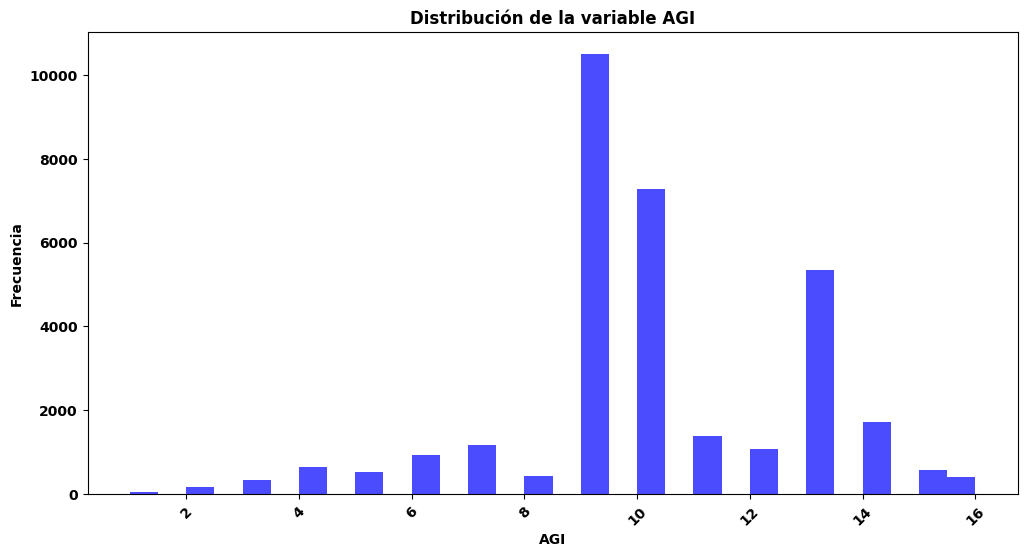

In [30]:
# Graficar la distribución con Seaborn

plt.figure(figsize=(12, 6))
plt.hist(df['AGI'], bins=30, color='blue', alpha=0.7)
plt.xlabel('AGI')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable AGI')
plt.xticks(rotation=45) 
plt.show()

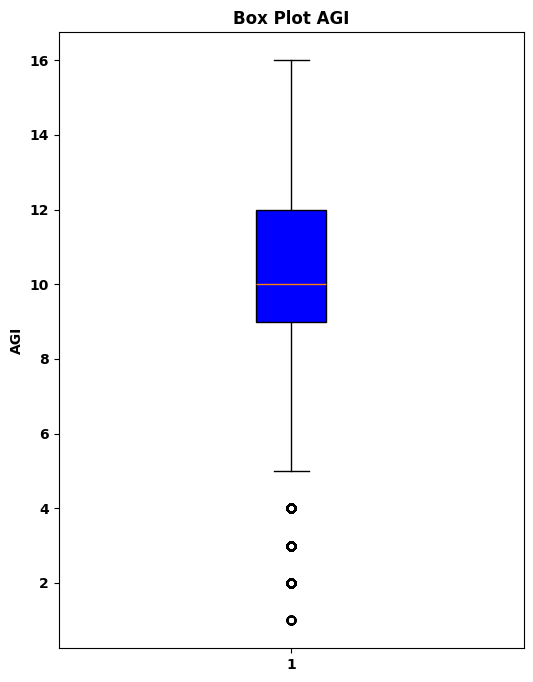

In [31]:
# Crear el box plot vertical
plt.figure(figsize=(6, 8))  # Ajusta el tamaño del gráfico
plt.boxplot(df['AGI'], vert=True, patch_artist=True, boxprops=dict(facecolor="blue"))
plt.title('Box Plot AGI')
plt.ylabel('AGI')
plt.show()

Forma numérica de identificación de outliers

In [32]:
def percentile_outliers(df, col:str, var:float = 0.05):
    lower = df[col].quantile(var)
    upper = df[col].quantile(1-var)
    df_percent = df.copy(deep=True)
    df_percent["lower"] = lower
    df_percent["upper"] = upper
    outliers = df_percent[((df_percent[col] < lower) | (df_percent[col] > upper))]
    return outliers[[col, 'lower', 'upper']]

def IQR_outliers(df, col:str):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df_IQR = df.copy(deep=True)
    df_IQR["lower"] = lower
    df_IQR["upper"] = upper
    outliers = df_IQR[((df_IQR[col] < lower) | (df_IQR[col] > upper))]
    return outliers[[col, 'lower', 'upper']]

def zscore_outliers(df, col:str):
    mean = np.mean(df[col])
    std = np.std(df[col])
    df_zscore = df.copy(deep=True)
    df_zscore['z-score'] = (df_zscore[col] - mean) / std
    outliers = df_zscore[abs(df_zscore['z-score']) > 3]
    return outliers[[col, 'z-score']]

In [33]:
df_IQR = IQR_outliers(df, 'AGI')
df_IQR
#print("Interquartile range: " + str(df_IQR.index.to_list())) 

,AGI,lower,upper
15,4,4.5,16.5
56,3,4.5,16.5
61,4,4.5,16.5
79,4,4.5,16.5
160,2,4.5,16.5
...,...,...,...
32431,4,4.5,16.5
32432,1,4.5,16.5
32448,4,4.5,16.5
32479,4,4.5,16.5


In [34]:
df_per=percentile_outliers(df, 'AGI', 0.01)
df_per

,AGI,lower,upper
160,2,3.0,16.0
221,2,3.0,16.0
224,1,3.0,16.0
416,2,3.0,16.0
463,2,3.0,16.0
...,...,...,...
32306,2,3.0,16.0
32359,1,3.0,16.0
32403,2,3.0,16.0
32425,2,3.0,16.0


In [35]:
zs=zscore_outliers(df, 'AGI')
zs

,AGI,z-score
160,2,-3.140957
221,2,-3.140957
224,1,-3.529656
416,2,-3.140957
463,2,-3.140957
...,...,...
32306,2,-3.140957
32359,1,-3.529656
32403,2,-3.140957
32425,2,-3.140957


Eliminamos los outliers

In [36]:
outlier_indices = zs.index.tolist()
#outlier_indices
df_filtrado = df.drop(outlier_indices)
df_filtrado

,AAGE,ACLSWKR,ADTIND,ADTOCC,AGI,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,...,PENATVTY,PRCITSHP,PTOTVAL,SEOTR,TAXINC,VETQVA,VETYN,WKSWORK,YEAR,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32557,37.0,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32558,37.0,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32559,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 4. Transformaciones variables continuas

#### 4.1 Transformacion logaritmica

In [37]:
df['log_AGI'] = np.log(df['AGI'])
df['log_AGI']

0        2.564949
1        2.564949
2        2.197225
3        1.945910
4        2.564949
           ...   
32556    2.484907
32557    2.197225
32558    2.197225
32559    2.197225
32560    2.197225
Name: log_AGI, Length: 32561, dtype: float64

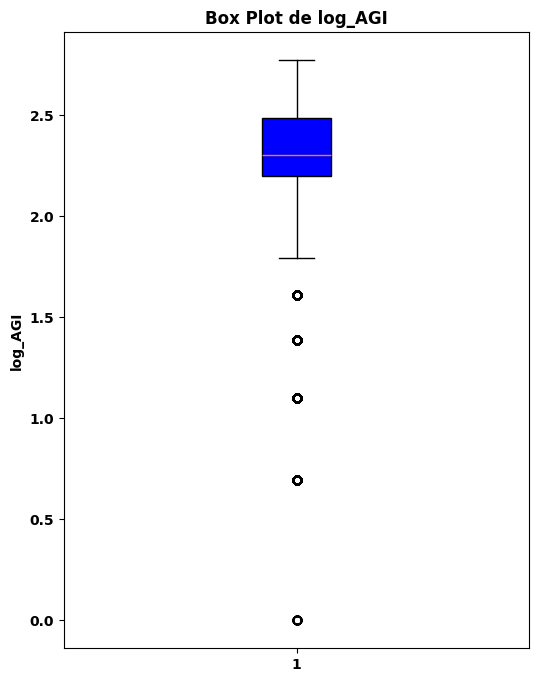

In [38]:
# Crear el box plot vertical
plt.figure(figsize=(6, 8))  # Ajusta el tamaño del gráfico
plt.boxplot(df['log_AGI'], vert=True, patch_artist=True, boxprops=dict(facecolor="blue"))
plt.title('Box Plot de log_AGI')
plt.ylabel('log_AGI')
plt.show()

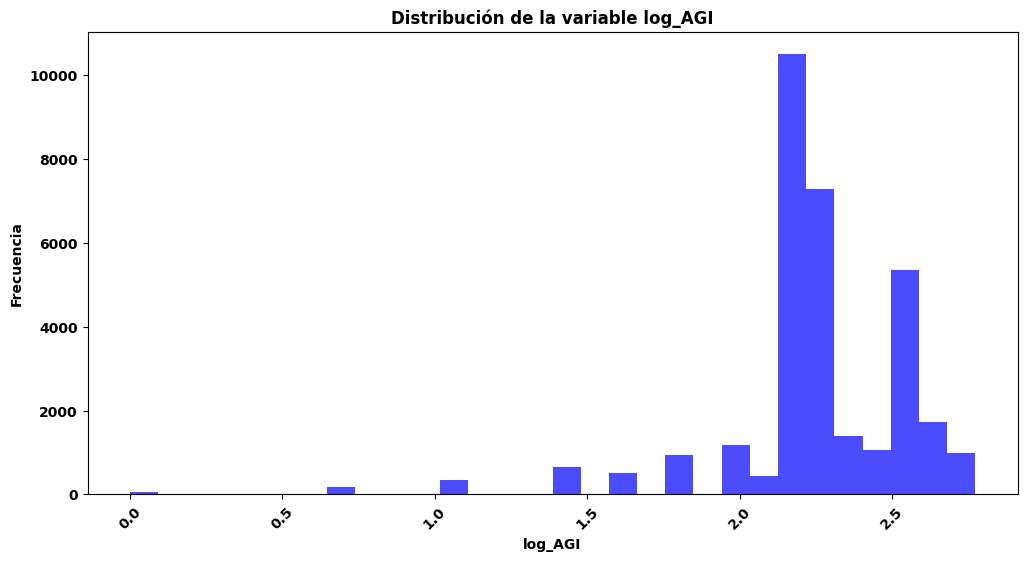

In [39]:
# Graficar la distribución con Seaborn

plt.figure(figsize=(12, 6))
plt.hist(df['log_AGI'], bins=30, color='blue', alpha=0.7)
plt.xlabel('log_AGI')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable log_AGI')
plt.xticks(rotation=45) 
plt.show()

#### 4.2 Discretización

##### Ordinal uniform

In [40]:
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df['dis_AGI']=enc.fit_transform(df[['AGI']])
df['dis_AGI'].unique()
#df['dis_MARSUPWRT']

array([4., 2., 1., 3., 0.])

In [41]:
enc.fit_transform(df[['AGI']])

array([[4.],
       [4.],
       [2.],
       ...,
       [2.],
       [2.],
       [2.]], shape=(32561, 1))

In [42]:
pivot = df.pivot_table(
    values='AGI',             # Variable numérica
    index='dis_AGI',          # Variable categórica
    aggfunc=['count', 'max', 'min'] # Funciones agregadas: conteo, máximo y mínimo
)

# Renombrar columnas para claridad
pivot.columns = ['Conteo', 'Máximo', 'Mínimo']
pivot.reset_index(inplace=True)

print(pivot)

   dis_AGI  Conteo  Máximo  Mínimo
0      0.0     552       3       1
1      1.0    2093       6       4
2      2.0   12109       9       7
3      3.0    9740      12      10
4      4.0    8067      16      13


##### Ordinal quantile

In [43]:
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df['dis_AGE']=enc.fit_transform(df[['AAGE']])
df['dis_AGE'].unique()
#df['dis_MARSUPWRT']

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([1., 2., 0.])

In [44]:
pivot = df.pivot_table(
    values='AAGE',             # Variable numérica
    index='dis_AGE',          # Variable categórica
    aggfunc=['count', 'max', 'min'] # Funciones agregadas: conteo, máximo y mínimo
)

# Renombrar columnas para claridad
pivot.columns = ['Conteo', 'Máximo', 'Mínimo']
pivot.reset_index(inplace=True)

print(pivot)

   dis_AGE  Conteo  Máximo  Mínimo
0      0.0   10517    33.0    17.0
1      1.0   10625    39.0    34.0
2      2.0   11419    90.0    40.0


##### Onehot dense

In [45]:
#KBinsDiscretizer devuelve una matriz de 10 columnas (bins) cada tramos de la discretizacion crea una columna con valor 1 o 0
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=3, encode='onehot-dense', strategy='uniform')
valores_discretizados = enc.fit_transform(df[['AGI']])
valores_discretizados

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(32561, 3))

In [46]:
# Convertir la salida en un DataFrame y unir con el original
df_discretizado = pd.DataFrame(valores_discretizados, columns=[f'Bin_{i}' for i in range(valores_discretizados.shape[1])])
# Mostrar el DataFrame final
#print(df_final)
df_final = df.join(df_discretizado)
df_final

,AAGE,ACLSWKR,ADTIND,ADTOCC,AGI,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,...,VETYN,WKSWORK,YEAR,income,log_AGI,dis_AGI,dis_AGE,Bin_0,Bin_1,Bin_2
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,2.564949,4.0,1.0,0.0,0.0,1.0
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,NaN,NaN,NaN,NaN,2.564949,4.0,2.0,0.0,0.0,1.0
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,2.197225,2.0,1.0,0.0,1.0,0.0
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,NaN,NaN,NaN,NaN,1.945910,2.0,2.0,0.0,1.0,0.0
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,NaN,NaN,NaN,NaN,2.564949,4.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,...,NaN,NaN,NaN,NaN,2.484907,3.0,0.0,0.0,0.0,1.0
32557,37.0,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,...,NaN,NaN,NaN,NaN,2.197225,2.0,1.0,0.0,1.0,0.0
32558,37.0,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,...,NaN,NaN,NaN,NaN,2.197225,2.0,1.0,0.0,1.0,0.0
32559,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,...,NaN,NaN,NaN,NaN,2.197225,2.0,0.0,0.0,1.0,0.0


##### Onehot

In [47]:
enc = KBinsDiscretizer(n_bins=3, encode='onehot', strategy='uniform')

# Aplicar la transformación
valores_discretizados = enc.fit_transform(df[['AGI']])

# Convertir la matriz dispersa a un DataFrame y unirla con el original
df_discretizado = pd.DataFrame(valores_discretizados.toarray(), columns=[f'Bin_{i}' for i in range(valores_discretizados.shape[1])])
df_final = df.join(df_discretizado)

# Mostrar el DataFrame final con la discretización
print(df_final)

       AAGE           ACLSWKR  ADTIND      ADTOCC  AGI                AHGA  \
0      39.0         State-gov   77516   Bachelors   13       Never-married   
1      50.0  Self-emp-not-inc   83311   Bachelors   13  Married-civ-spouse   
2      38.0           Private  215646     HS-grad    9            Divorced   
3      53.0           Private  234721        11th    7  Married-civ-spouse   
4      28.0           Private  338409   Bachelors   13  Married-civ-spouse   
...     ...               ...     ...         ...  ...                 ...   
32556  27.0           Private  257302  Assoc-acdm   12  Married-civ-spouse   
32557  37.0           Private  154374     HS-grad    9  Married-civ-spouse   
32558  37.0           Private  151910     HS-grad    9             Widowed   
32559  22.0           Private  201490     HS-grad    9       Never-married   
32560  37.0      Self-emp-inc  287927     HS-grad    9  Married-civ-spouse   

                 AHRSPAY         AHSCOL AMARITL  AMJIND  ...  V

In [48]:
df_final.head(10)

,AAGE,ACLSWKR,ADTIND,ADTOCC,AGI,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,...,VETYN,WKSWORK,YEAR,income,log_AGI,dis_AGI,dis_AGE,Bin_0,Bin_1,Bin_2
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,2.564949,4.0,1.0,0.0,0.0,1.0
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,NaN,NaN,NaN,NaN,2.564949,4.0,2.0,0.0,0.0,1.0
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,NaN,NaN,NaN,NaN,2.197225,2.0,1.0,0.0,1.0,0.0
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,NaN,NaN,NaN,NaN,1.945910,2.0,2.0,0.0,1.0,0.0
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,NaN,NaN,NaN,NaN,2.564949,4.0,0.0,0.0,0.0,1.0
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,...,NaN,NaN,NaN,NaN,2.639057,4.0,1.0,0.0,0.0,1.0
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,...,NaN,NaN,NaN,NaN,1.609438,1.0,2.0,1.0,0.0,0.0
7,52.0,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,NaN,NaN,NaN,NaN,2.197225,2.0,2.0,0.0,1.0,0.0
8,31.0,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,...,NaN,NaN,NaN,NaN,2.639057,4.0,0.0,0.0,0.0,1.0
9,42.0,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,NaN,NaN,NaN,NaN,2.564949,4.0,2.0,0.0,0.0,1.0


##### Scaling

In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
min_max_scaler = MinMaxScaler()
df['minmax_AGI'] = min_max_scaler.fit_transform(df[['AGI']])
df['minmax_AGI']

0        0.800000
1        0.800000
2        0.533333
3        0.400000
4        0.800000
           ...   
32556    0.733333
32557    0.533333
32558    0.533333
32559    0.533333
32560    0.533333
Name: minmax_AGI, Length: 32561, dtype: float64

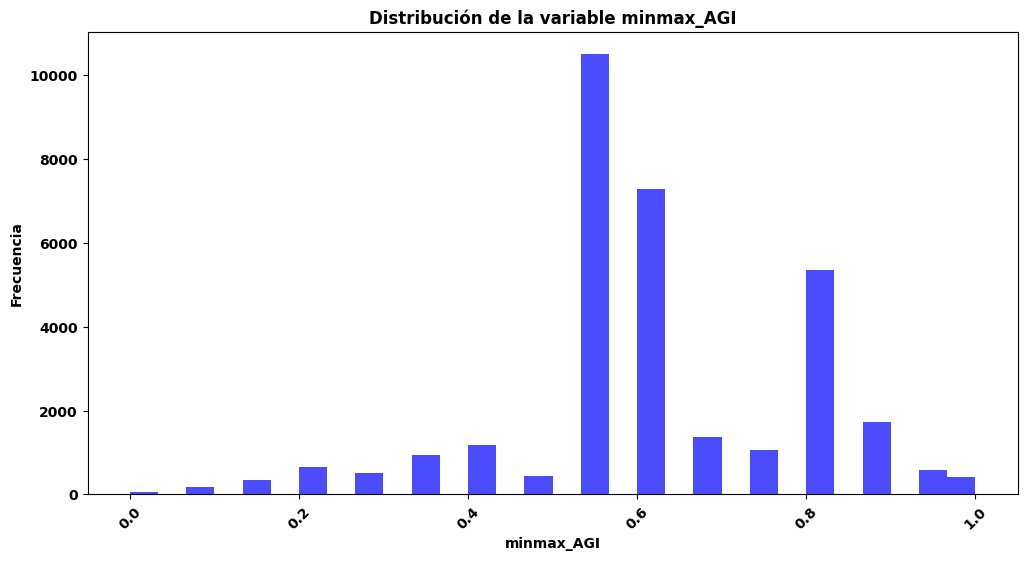

In [50]:

plt.figure(figsize=(12, 6))
plt.hist(df['minmax_AGI'], bins=30, color='blue', alpha=0.7)
plt.xlabel('minmax_AGI')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable minmax_AGI')
plt.xticks(rotation=45) 
plt.show()

In [51]:
print(df.columns.tolist())

['AAGE', 'ACLSWKR', 'ADTIND', 'ADTOCC', 'AGI', 'AHGA', 'AHRSPAY', 'AHSCOL', 'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX', 'AUNMEM', 'AUNTYPE', 'AWKSTAT', 'CAPGAIN', 'CAPLOSS', 'DIVVAL', 'FEDTAX', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL', 'MARSUPWT', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN', 'NOEMP', 'PARENT', 'PEARNVAL', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'PTOTVAL', 'SEOTR', 'TAXINC', 'VETQVA', 'VETYN', 'WKSWORK', 'YEAR', 'income', 'log_AGI', 'dis_AGI', 'dis_AGE', 'minmax_AGI']


In [52]:
media = df['minmax_AGI'].mean()
desviacion = df['minmax_AGI'].std()
print(media, desviacion)

0.6053786226876734 0.17151468880449255


In [53]:
std_scaler = StandardScaler()
df['std_AGI'] = std_scaler.fit_transform(df[['AGI']])
df['std_AGI']

0        1.134739
1        1.134739
2       -0.420060
3       -1.197459
4        1.134739
           ...   
32556    0.746039
32557   -0.420060
32558   -0.420060
32559   -0.420060
32560   -0.420060
Name: std_AGI, Length: 32561, dtype: float64

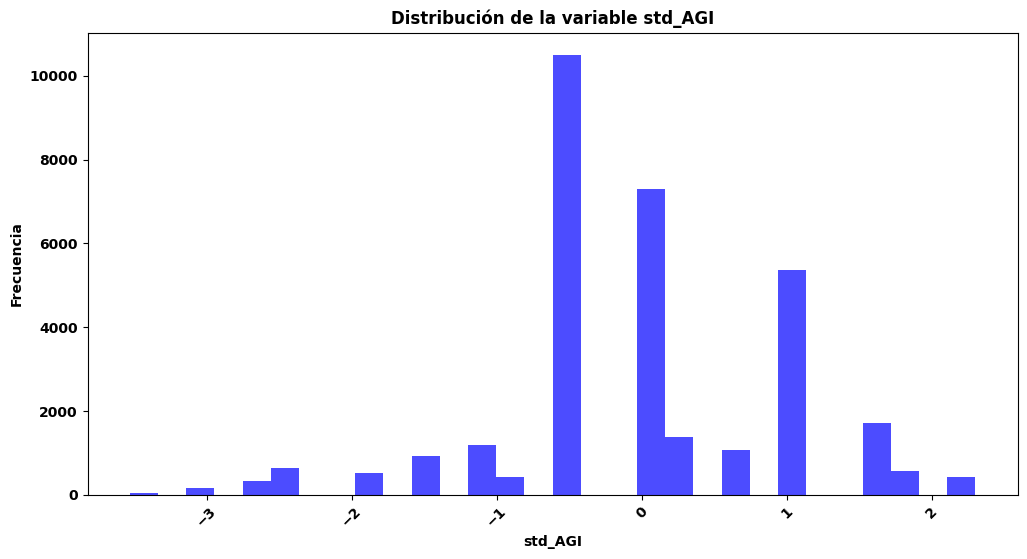

In [54]:
plt.figure(figsize=(12, 6))
plt.hist(df['std_AGI'], bins=30, color='blue', alpha=0.7)
plt.xlabel('std_AGI')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable std_AGI')
plt.xticks(rotation=45) 
plt.show()

In [55]:
media = df['std_AGI'].mean()
desviacion = df['std_AGI'].std()
print(media, desviacion)

1.4795245073718497e-16 1.0000153561474507


#### 5. Pipeline

In [56]:
from sklearn.preprocessing import FunctionTransformer, normalize, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [57]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols

In [58]:
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['ACLSWKR', 'ADTOCC', 'AHGA', 'AHRSPAY', 'AHSCOL', 'AMARITL', 'AMJIND', 'ASEX', 'AUNMEM']
['AAGE', 'ADTIND', 'AGI', 'AMJOCC', 'ARACE', 'AREORGN', 'AUNTYPE', 'AWKSTAT', 'CAPGAIN', 'CAPLOSS', 'DIVVAL', 'FEDTAX', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL', 'MARSUPWT', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN', 'NOEMP', 'PARENT', 'PEARNVAL', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'PTOTVAL', 'SEOTR', 'TAXINC', 'VETQVA', 'VETYN', 'WKSWORK', 'YEAR', 'income', 'log_AGI', 'dis_AGI', 'dis_AGE', 'minmax_AGI', 'std_AGI']


In [ ]:
def MyHotEncoder(X):
    from sklearn.preprocessing import OneHotEncoder
    # Crear un objeto OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False)
    cat_vbles = tipo_variables(X)[1]
    #El parámetro sparse_output=False asegura que la salida sea un array denso 
    #(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.   
    X = X.reset_index(drop=True)  
    
    for i in cat_vbles:
        encoded_data = encoder.fit_transform(X[[i]])
        column_names = encoder.get_feature_names_out([i])
        encoded_X = pd.DataFrame(encoded_data, columns=column_names)
        X = pd.concat([X, encoded_X], axis=1)
    X = X.drop(columns=cat_vbles)
    return X

In [60]:
def quitar_nulos(df):
    df_sin_nulos = df.dropna()
    return df_sin_nulos

In [61]:
def normalizar(df):
    df_norm= preprocessing.normalize(df)
    return df_norm

In [62]:
def escalar(df):
    scaler = StandardScaler()
    df_scaled= scaler.fit_transform(df)
    df_scaled=pd.DataFrame(df_scaled, columns=df.columns)
    return df_scaled

In [63]:
def to_df(array):
    df_pca=pd.DataFrame(array, columns=['pca1', 'pca2'])
    return df_pca

In [64]:
pipeline = Pipeline([
    ('quitar_nulos', FunctionTransformer(quitar_nulos)),  # Paso 1: quita registros con nulos
    ('MyHotEncoder', FunctionTransformer(MyHotEncoder)),  # Paso 2: grestina variables c4tePCA
    ('escalar', FunctionTransformer(escalar))   ,         # Paso 3: escalar
    ('pca', PCA(n_components=2))  ,                       # Paso 4: PCA
    ('pasar a dataframe',FunctionTransformer(to_df))      # Paso5: PAsar a DataFrame
])    

In [65]:
# DIAGNÓSTICO - ejecuta esto antes del pipeline
import pandas as pd

# Paso 1: ver estado inicial
print("Shape inicial:", df.shape)
print("Nulos iniciales:", df.isnull().sum().sum())

# Paso 2: aplicar MyHotEncoder y ver resultado
df_encoded = MyHotEncoder(df)
print("\nShape tras MyHotEncoder:", df_encoded.shape)
print("Nulos tras MyHotEncoder:", df_encoded.isnull().sum().sum())

# Paso 3: aplicar quitar_nulos y ver cuántas filas quedan
df_sin_nulos = quitar_nulos(df_encoded)
print("\nShape tras quitar_nulos:", df_sin_nulos.shape)

Shape inicial: (32561, 52)
Nulos iniciales: 1041952



Shape tras MyHotEncoder: (32561, 147)
Nulos tras MyHotEncoder: 1041952

Shape tras quitar_nulos: (0, 147)


In [67]:
print("Total filas:", len(df))
print("Filas con al menos 1 nulo:", df.isnull().any(axis=1).sum())
print("Filas completamente limpias:", df.notna().all(axis=1).sum())
print("\nNulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total filas: 32561
Filas con al menos 1 nulo: 32561
Filas completamente limpias: 0

Nulos por columna:
AUNTYPE     32561
AWKSTAT     32561
CAPGAIN     32561
CAPLOSS     32561
DIVVAL      32561
FEDTAX      32561
FILESTAT    32561
GRINREG     32561
GRINST      32561
HHDFMX      32561
HHDREL      32561
MARSUPWT    32561
MIGMTR1     32561
MIGMTR3     32561
MIGMTR4     32561
MIGSAME     32561
MIGSUN      32561
NOEMP       32561
PARENT      32561
PEARNVAL    32561
PEFNTVTY    32561
PEMNTVTY    32561
PENATVTY    32561
PRCITSHP    32561
PTOTVAL     32561
SEOTR       32561
TAXINC      32561
VETQVA      32561
VETYN       32561
WKSWORK     32561
YEAR        32561
income      32561
dtype: int64


In [69]:
# Eliminar columnas que son 100% nulos
df_clean = df.dropna(axis=1, how='all')
print("Shape tras eliminar columnas vacías:", df_clean.shape)
print("Nulos restantes:", df_clean.isnull().sum().sum())

Shape tras eliminar columnas vacías: (32561, 20)
Nulos restantes: 0


In [ ]:
X_pca = pipeline.fit_transform(df_clean)
X_pca

,pca1,pca2
0,2.274661,-2.472655
1,3.274655,1.024031
2,-1.647037,-0.140173
3,-2.367543,2.345187
4,1.975846,-2.489171
...,...,...
32556,1.044058,-1.890250
32557,0.051833,2.984541
32558,-1.990131,-1.688252
32559,-2.115256,-1.568983


In [71]:
# Extraer componentes
componente_1 = X_pca['pca1']
componente_2 = X_pca['pca2']

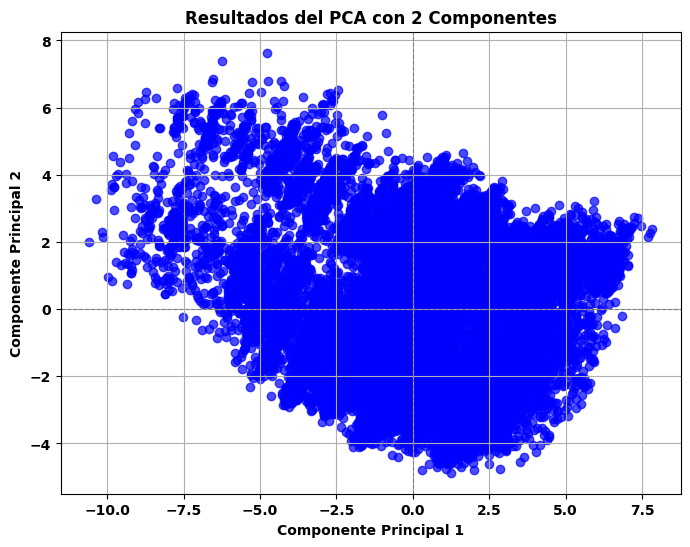

In [72]:
# Graficar los resultados del PCA
plt.figure(figsize=(8, 6))
plt.scatter(componente_1, componente_2, c='blue', alpha=0.7)
plt.title('Resultados del PCA con 2 Componentes')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True)
plt.show()